In [273]:
# libraries
import pandas as pd
import numpy as np
import cv2 as cv
import torch
import torch.nn as nn
import torch.optim as optim

In [274]:
import os 

def im_to_array(path, size=(128,128)):
    im_list = []
    for filename in os.listdir(path):
        if filename.endswith('.jpg'):
            im = cv.imread(os.path.join(path, filename), cv.IMREAD_GRAYSCALE)
            im = cv.resize(im, size)  
            im = im/ 255.0                       
            im_list.append(im.flatten())
            
    return np.array(im_list).reshape(len(im_list), -1)

In [275]:
# using cv reading an image
im_test_dog = cv.imread("D:\\ITC\\Year3\\I3 s2\\Introduction_Machinlearning\\Project\\project4\\Test\\Dog\\dog (1).jpg", cv.IMREAD_GRAYSCALE)
print(im_test_dog.shape)

im_test_cat = cv.imread("D:\\ITC\\Year3\\I3 s2\\Introduction_Machinlearning\\Project\\project4\\Test\\Cat\\cat (1).jpg", cv.IMREAD_GRAYSCALE)
print(im_test_cat.shape)

(1280, 960)
(1280, 720)


In [276]:
im_train_dog = im_to_array(r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\Train\Dog")
y_train_dog = np.ones(im_train_dog.shape[0])

im_train_cat = im_to_array(r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\Train\Cat")
y_train_cat = np.zeros(im_train_cat.shape[0])

X_train = np.concatenate((im_train_dog, im_train_cat), axis=0)
y_train = np.concatenate((y_train_dog, y_train_cat), axis=0)

print(X_train.shape)
print(y_train.shape)




(160, 16384)
(160,)


In [277]:
np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)

In [278]:

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([160, 16384])
torch.Size([160])


In [279]:
# define model
def my_ANN (X, w1,b1,w2,b2,w3,b3):
    # layer 1
    Z1 = torch.matmul(X,w1) + b1
    A1 = torch.sigmoid(Z1)
    # layer 2
    Z2 = torch.matmul(A1,w2) + b2
    A2 = torch.sigmoid(Z2)
    # layer 3
    Z3 = torch.matmul(A2,w3) + b3
    return Z3

In [280]:
# Training
W1 = torch.randn(16384,128, requires_grad= True)
b1 = torch.zeros(1, 128, requires_grad= True)
W2 = torch.randn(128, 64, requires_grad =True)
b2 = torch.zeros(1, 64, requires_grad= True)
W3 = torch.randn(64, 2, requires_grad= True)
b3 = torch.zeros(1, 2, requires_grad= True)

cost_func = nn.CrossEntropyLoss()
optimizer = optim.SGD([W1,b1,W2,b2,W3,b3], lr=0.1)

for epoch in range(1, 201):
    Z = my_ANN(X_train_tensor, W1, b1, W2, b2, W3, b3)
    loss = cost_func(Z, y_train_tensor)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f"Epoch: {epoch:03d}, Loss: {loss.item():.4f}")

Epoch: 001, Loss: 1.6812
Epoch: 002, Loss: 1.1948
Epoch: 003, Loss: 1.0825
Epoch: 004, Loss: 1.0117
Epoch: 005, Loss: 0.9507
Epoch: 006, Loss: 0.8950
Epoch: 007, Loss: 0.8492
Epoch: 008, Loss: 0.8112
Epoch: 009, Loss: 0.7779
Epoch: 010, Loss: 0.7506
Epoch: 011, Loss: 0.7262
Epoch: 012, Loss: 0.7052
Epoch: 013, Loss: 0.6865
Epoch: 014, Loss: 0.6695
Epoch: 015, Loss: 0.6541
Epoch: 016, Loss: 0.6405
Epoch: 017, Loss: 0.6284
Epoch: 018, Loss: 0.6172
Epoch: 019, Loss: 0.6067
Epoch: 020, Loss: 0.5966
Epoch: 021, Loss: 0.5870
Epoch: 022, Loss: 0.5776
Epoch: 023, Loss: 0.5685
Epoch: 024, Loss: 0.5595
Epoch: 025, Loss: 0.5505
Epoch: 026, Loss: 0.5411
Epoch: 027, Loss: 0.5309
Epoch: 028, Loss: 0.5201
Epoch: 029, Loss: 0.5106
Epoch: 030, Loss: 0.5031
Epoch: 031, Loss: 0.4962
Epoch: 032, Loss: 0.4896
Epoch: 033, Loss: 0.4831
Epoch: 034, Loss: 0.4767
Epoch: 035, Loss: 0.4702
Epoch: 036, Loss: 0.4635
Epoch: 037, Loss: 0.4567
Epoch: 038, Loss: 0.4502
Epoch: 039, Loss: 0.4440
Epoch: 040, Loss: 0.4383


In [281]:
# Evaluate
Z= my_ANN(X_train_tensor, W1, b1, W2, b2, W3, b3)
y_pred = torch.argmax(Z,dim=1)
acc = torch.mean((y_pred == y_train_tensor).float())
print(f"Accuracy: {acc*100:.2f}%")

Accuracy: 96.88%


In [282]:
im_test_dog = im_to_array(r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\Test\Dog")
y_test_dog = np.ones(im_test_dog.shape[0])

im_test_cat = im_to_array(r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\Test\Cat")
y_test_cat = np.zeros(im_test_cat.shape[0])

X_test = np.concatenate((im_test_dog, im_test_cat), axis=0)
y_test = np.concatenate((y_test_dog, y_test_cat), axis=0)

print(X_test.shape)
print(y_test.shape)

(40, 16384)
(40,)


In [283]:
np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)

In [284]:

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [285]:
Z_test = my_ANN(X_test_tensor, W1, b1, W2, b2, W3, b3)
y_pred_test = torch.argmax(Z_test, dim=1)
acc = torch.mean((y_pred_test == y_test_tensor).float())
print(f"Accuracy: {acc*100:.2f}%")


Accuracy: 65.00%


In [286]:
print(f"Train range: {X_train_tensor.min():.4f} to {X_train_tensor.max():.4f}")
print(f"Test range:  {X_test_tensor.min():.4f} to {X_test_tensor.max():.4f}")

Train range: 0.0000 to 1.0000
Test range:  0.0000 to 1.0000


Prediction : Dog (91.5% confident)
Confidence : Cat 8.5% | Dog 91.5%


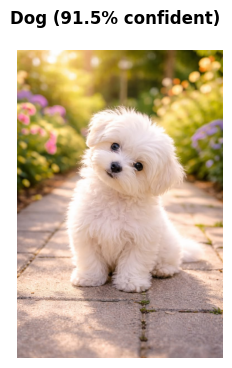

In [292]:
import matplotlib.pyplot as plt

def predict_image(image_path, size=(128, 128)):

    img_color = cv.imread(image_path)
    img_color = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)


    im = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    im = cv.resize(im, size)
    im = im / 255.0
    im = im.flatten()
    
    tensor = torch.tensor(im, dtype=torch.float32).unsqueeze(0)


    with torch.no_grad():
        output = my_ANN(tensor, W1, b1, W2, b2, W3, b3)
        _, predicted = torch.max(output, 1)
        confidence = torch.softmax(output, dim=1)

    cat_conf = confidence[0][0].item() * 100
    dog_conf = confidence[0][1].item() * 100

    if predicted.item() == 0:
        label = f"Cat ({cat_conf:.1f}% confident)"
    else:
        label = f"Dog ({dog_conf:.1f}% confident)"

    print(f"Prediction : {label}")
    print(f"Confidence : Cat {cat_conf:.1f}% | Dog {dog_conf:.1f}%")


    plt.figure(figsize=(4, 4))
    plt.suptitle(label, fontsize=12, weight="bold")
    plt.imshow(img_color)   
    plt.axis("off")
    plt.xlabel(f"Cat {cat_conf:.1f}% | Dog {dog_conf:.1f}%")
    plt.show()

    return label

label = predict_image("D:/ITC/Year3/I3 s2/Introduction_Machinlearning/Project/project4/example/2.jpg")

In [288]:
import numpy as np

np.save("W1.npy", W1.detach().numpy())
np.save("b1.npy", b1.detach().numpy())
np.save("W2.npy", W2.detach().numpy())
np.save("b2.npy", b2.detach().numpy())
np.save("W3.npy", W3.detach().numpy())
np.save("b3.npy", b3.detach().numpy())
print("Saved!")

Saved!


In [289]:
# Save new weights after good training
torch.save({
    "W1": W1.detach(), "b1": b1.detach(),
    "W2": W2.detach(), "b2": b2.detach(),
    "W3": W3.detach(), "b3": b3.detach()
}, r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\weights.pth")
